# **K-Means Clustering**

In [1]:
# Install required libraries
!pip install -q scikit-learn matplotlib seaborn

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.datasets import load_iris

In [2]:
X, y_true = load_iris(return_X_y=True)
# Selecting the first two features
X = X[:, :2]
df = pd.DataFrame(X, columns=['sepal length (cm)', 'sepal width (cm)'])

In [3]:
df.head()

,sepal length (cm),sepal width (cm)
0,5.1,3.5
1,4.9,3.0
2,4.7,3.2
3,4.6,3.1
4,5.0,3.6


In [4]:
# Select features
features = ['sepal length (cm)', 'sepal width (cm)']
X = df[features].copy()

In [5]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

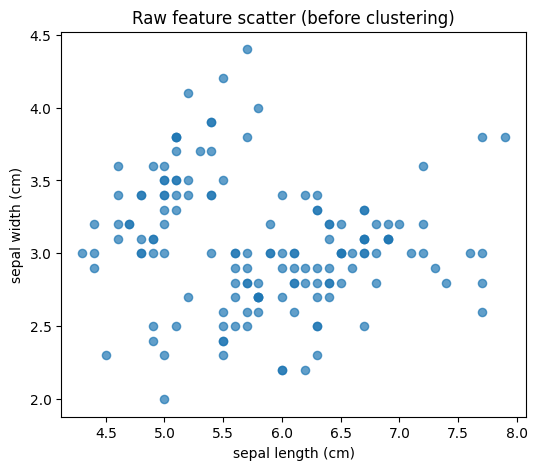

In [6]:
# Scatter plot raw features
plt.figure(figsize=(6,5))
plt.scatter(X.values[:,0], X.values[:,1], s=35, alpha=0.7)
plt.xlabel(X.columns[0]); plt.ylabel(X.columns[1])
plt.title("Raw feature scatter (before clustering)")
plt.show()

In [7]:
# Elbow & silhouette method
inertias, sil_scores = [], []
ks = range(2,11)
for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

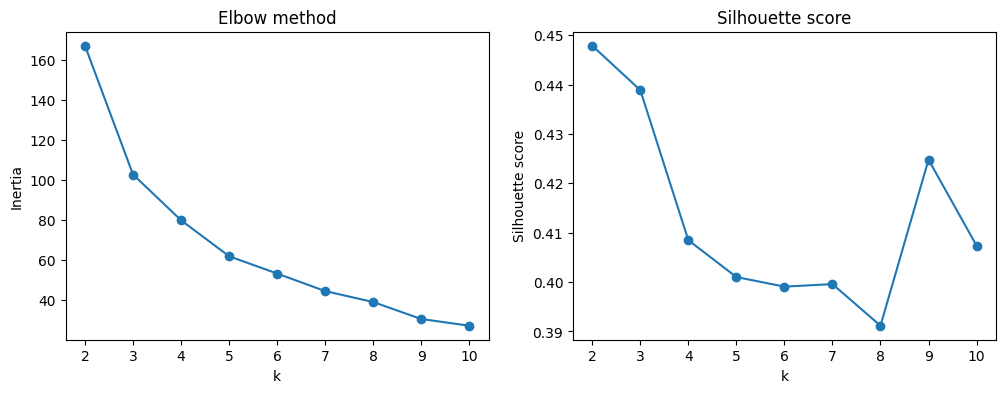

In [8]:
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(ks, inertias, '-o')
plt.xlabel('k'); plt.ylabel('Inertia'); plt.title('Elbow method')

plt.subplot(1,2,2)
plt.plot(ks, sil_scores, '-o')
plt.xlabel('k'); plt.ylabel('Silhouette score'); plt.title('Silhouette score')
plt.show()

In [9]:
print("Silhouette scores:", dict(zip(ks, np.round(sil_scores,3))))

Silhouette scores: {2: np.float64(0.448), 3: np.float64(0.439), 4: np.float64(0.408), 5: np.float64(0.401), 6: np.float64(0.399), 7: np.float64(0.4), 8: np.float64(0.391), 9: np.float64(0.425), 10: np.float64(0.407)}


In [10]:
# Fit chosen k
k = 2
km = KMeans(n_clusters=k, random_state=42, n_init=10)
labels = km.fit_predict(X_scaled)
centers_scaled = km.cluster_centers_
centers = scaler.inverse_transform(centers_scaled)

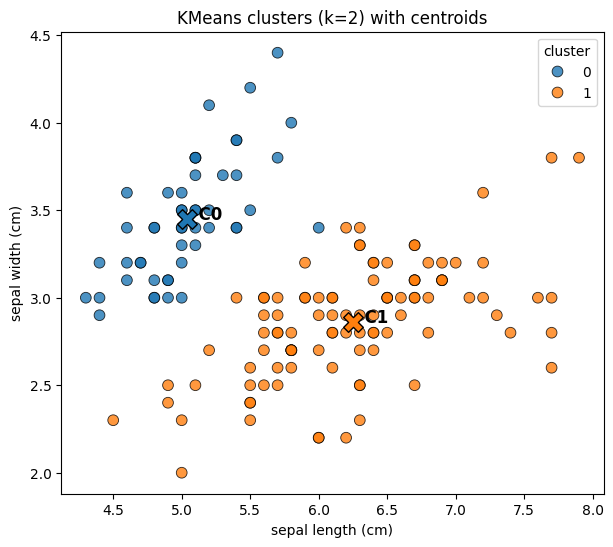

In [11]:
# Attach labels for plotting
plot_df = X.copy()
plot_df['cluster'] = labels

plt.figure(figsize=(7,6))
palette = sns.color_palette('tab10', n_colors=k)
sns.scatterplot(x=plot_df.columns[0], y=plot_df.columns[1], hue='cluster',
                data=plot_df, palette=palette, s=60, alpha=0.8, edgecolor='k')
for i, c in enumerate(centers):
    plt.scatter(c[0], c[1], marker='X', s=200, c=[palette[i]], edgecolor='k')
    plt.text(c[0], c[1], f'  C{i}', fontsize=12, weight='bold')
plt.title(f'KMeans clusters (k={k}) with centroids')
plt.show()

In [12]:
# Centroid table and cluster sizes
cluster_sizes = pd.Series(labels).value_counts().sort_index()
centroid_df = pd.DataFrame(centers, columns=X.columns)
centroid_df['size'] = cluster_sizes.values
centroid_df.index = [f'Cluster_{i}' for i in range(len(centroid_df))]

In [13]:
centroid_df

,sepal length (cm),sepal width (cm),size
Cluster_0,5.036,3.450,50
Cluster_1,6.247,2.861,100


In [14]:
# Silhouette score & sample cluster members
sil = silhouette_score(X_scaled, labels)
print(f"Silhouette score (k={k}):", round(sil, 2))

Silhouette score (k=2): 0.45


In [15]:
df_with_clusters = X.copy()
df_with_clusters['cluster'] = labels
df_with_clusters.groupby('cluster').head(5)

,sepal length (cm),sepal width (cm),cluster
0,5.1,3.5,0
1,4.9,3.0,0
2,4.7,3.2,0
3,4.6,3.1,0
4,5.0,3.6,0
41,4.5,2.3,1
50,7.0,3.2,1
51,6.4,3.2,1
52,6.9,3.1,1
53,5.5,2.3,1


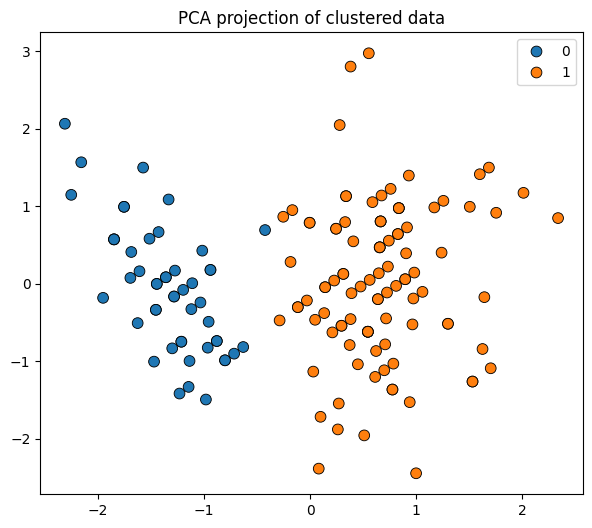

In [16]:
# PCA projection for higher-dimension data
pca = PCA(n_components=2)
proj = pca.fit_transform(X_scaled)
plt.figure(figsize=(7,6))
sns.scatterplot(x=proj[:,0], y=proj[:,1], hue=labels, palette=palette,
                s=60, edgecolor='k')
plt.title('PCA projection of clustered data')
plt.show()

In [17]:
# Animation: show how centroids move across iterations
from matplotlib.animation import FuncAnimation

# Initialize random centers for demonstration
np.random.seed(42)
k = 3
centers = X_scaled[np.random.choice(len(X_scaled), k, replace=False)]

fig, ax = plt.subplots(figsize=(7,6))

def update(frame):
    global centers
    ax.clear()
    # Assign clusters
    labels = np.argmin(((X_scaled[:, None, :] - centers[None, :, :])**2).sum(axis=2), axis=1)
    # Plot points
    for i in range(k):
        ax.scatter(X_scaled[labels==i,0], X_scaled[labels==i,1], s=30, alpha=0.6, label=f'Cluster {i}')
    # Plot centers
    ax.scatter(centers[:,0], centers[:,1], c='black', marker='X', s=200)
    ax.set_title(f'Iteration {frame+1}')
    # Recompute centers
    new_centers = np.array([X_scaled[labels==i].mean(axis=0) for i in range(k)])
    centers = new_centers

ani = FuncAnimation(fig, update, frames=5, repeat=False)
plt.close()
from IPython.display import HTML
HTML(ani.to_jshtml())